# Used Car Price Prediction – Regression Models

## ITAI 1371 | Final Project | Spring 2026 | Group 5



---

## Table of Contents

1. Dataset Upload and Initialization  
2. Data Partitioning (Training / Validation / Testing – 70/15/15)  
3. Feature Scaling and Preparation  
4. Model Building  
   - 4.1 Linear Regression Model  
   - 4.2 Decision Tree Model  
   - 4.3 Random Forest Model  
   - 4.4 Gradient Boosting Model  
   - 4.5 K-Nearest Neighbors Model  
5. Performance Evaluation and Comparison  
6. Ensemble Learning Methods  
   - 6.1 Voting Regressor (Best 3 Models)  
   - 6.2 Bayesian-Based Ensemble  
7. Testing and Final Performance Check  
8. Overall Results Summary  

<a id='1'></a>
## 1. Setup & Data Load

In [128]:
import pandas as pd
import numpy as np

df = pd.read_csv('final_cleaned_dataset_readable.csv')

print("Dataset loaded successfully ✅")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully ✅
Shape: (5973, 26)


,Age,kmDriven,AskPrice,Brand_Audi,Brand_BMW,Brand_Chevrolet,Brand_Ford,Brand_Honda,Brand_Hyundai,Brand_Kia,...,Brand_Tata,Brand_Toyota,Brand_Volkswagen,Transmission_Automatic,Transmission_Manual,Owner_first,Owner_second,FuelType_Diesel,FuelType_Hybrid/CNG,FuelType_Petrol
0,5,16000.0000,12.9480,0,0,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,1
1,7,47600.0000,13.1204,0,0,0,0,0,1,0,...,0,0,0,1,0,1,0,0,0,1
2,9,80000.0000,13.2794,0,0,0,0,1,0,0,...,0,0,0,1,0,0,1,0,0,1
3,8,96000.0000,13.5278,0,0,0,0,0,0,0,...,0,0,0,0,1,1,0,1,0,0
4,1,9000.0000,14.1871,0,0,0,0,0,0,0,...,0,0,0,0,1,1,0,0,0,1


In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, BayesianRidge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor,
                               GradientBoostingRegressor,
                               VotingRegressor)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 4)
pd.set_option('display.float_format', '{:.4f}'.format)
print('Libraries loaded.')


Libraries loaded.


In [130]:
# Load the cleaned dataset (AskPrice already log1p-transformed)
df = pd.read_csv('final_cleaned_dataset_readable.csv')

# Safety check: apply log1p only if AskPrice is still in raw ₹ form
if df['AskPrice'].max() > 100:
    df['AskPrice'] = np.log1p(df['AskPrice'])
    print('log1p applied to AskPrice.')
else:
    print('AskPrice already in log-space — no transform needed.')

print(f'Dataset shape: {df.shape}')
print(f'AskPrice range: {df["AskPrice"].min():.2f} → {df["AskPrice"].max():.2f}')
df.head()


AskPrice already in log-space — no transform needed.
Dataset shape: (5973, 26)
AskPrice range: 9.62 → 17.03


,Age,kmDriven,AskPrice,Brand_Audi,Brand_BMW,Brand_Chevrolet,Brand_Ford,Brand_Honda,Brand_Hyundai,Brand_Kia,...,Brand_Tata,Brand_Toyota,Brand_Volkswagen,Transmission_Automatic,Transmission_Manual,Owner_first,Owner_second,FuelType_Diesel,FuelType_Hybrid/CNG,FuelType_Petrol
0,5,16000.0000,12.9480,0,0,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,1
1,7,47600.0000,13.1204,0,0,0,0,0,1,0,...,0,0,0,1,0,1,0,0,0,1
2,9,80000.0000,13.2794,0,0,0,0,1,0,0,...,0,0,0,1,0,0,1,0,0,1
3,8,96000.0000,13.5278,0,0,0,0,0,0,0,...,0,0,0,0,1,1,0,1,0,0
4,1,9000.0000,14.1871,0,0,0,0,0,0,0,...,0,0,0,0,1,1,0,0,0,1


<a id='2'></a>
## 2. Train / Validation / Test Split — 70 / 15 / 15

The dataset is split into training, validation, and test sets in a 70/15/15 ratio. This split is used to train the models, compare performance, and evaluate final results.

In [131]:
X = df.drop(columns=['AskPrice'])
y = df['AskPrice']

# Step 1: hold out 30% as temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42)

# Step 2: split temp equally → 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42)

print(f'Training set   : {X_train.shape[0]:,} rows  ({X_train.shape[0]/len(df)*100:.0f}%)')
print(f'Validation set : {X_val.shape[0]:,} rows  ({X_val.shape[0]/len(df)*100:.0f}%)')
print(f'Test set       : {X_test.shape[0]:,} rows  ({X_test.shape[0]/len(df)*100:.0f}%)')
print(f'Features       : {X_train.shape[1]}')


Training set   : 4,181 rows  (70%)
Validation set : 896 rows  (15%)
Test set       : 896 rows  (15%)
Features       : 25


<a id='3'></a>
## 3. Feature Scaling

In this step, selected numerical features are scaled using StandardScaler. The scaler is fitted on the training data and applied to validation and test sets.


In [132]:
scaler = StandardScaler()

X_train = X_train.copy()
X_val   = X_val.copy()
X_test  = X_test.copy()

num_cols = ['kmDriven', 'Age']
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val[num_cols]   = scaler.transform(X_val[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

print('Scaling complete.')
print(f'  kmDriven — train mean: {X_train["kmDriven"].mean():.4f}, std: {X_train["kmDriven"].std():.4f}')
print(f'  Age      — train mean: {X_train["Age"].mean():.4f}, std: {X_train["Age"].std():.4f}')


Scaling complete.
  kmDriven — train mean: -0.0000, std: 1.0001
  Age      — train mean: 0.0000, std: 1.0001


<a id='4'></a>
## 4. Model Training
In this step, multiple regression models are trained using the training dataset.

### 4.1 Linear Regression
Baseline regression model with a linear assumption between features and the target variable.

In [133]:
lr = LinearRegression()
lr.fit(X_train, y_train)
print('Linear Regression trained.')

# Top coefficients
coef_df = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': lr.coef_})
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index)
print('\nTop 10 most influential features:')
print(coef_df.head(10).to_string(index=False))


Linear Regression trained.

Top 10 most influential features:
            Feature  Coefficient
Brand_Mercedes-Benz       1.0076
          Brand_BMW       0.9812
      Brand_Renault      -0.6822
         Brand_Audi       0.6757
    Brand_Chevrolet      -0.6442
         Brand_Tata      -0.5780
                Age      -0.5040
       Brand_Toyota       0.4401
Brand_Maruti Suzuki      -0.4086
      Brand_Hyundai      -0.2806


### 4.2 Decision Tree Regressor
Non-linear model that splits data into decision-based regions.

In [134]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
print(f'Decision Tree trained. Max depth reached: {dt.get_depth()}')


Decision Tree trained. Max depth reached: 31


### 4.3 Random Forest Regressor
Ensemble model combining multiple decision trees to improve accuracy and reduce overfitting.

Random Forest trained (200 trees).


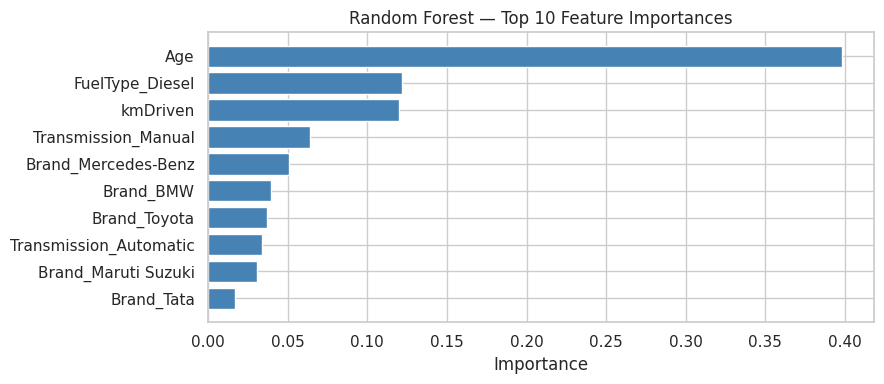

In [135]:
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
print('Random Forest trained (200 trees).')

# Feature importance
fi = pd.DataFrame({'Feature': X_train.columns, 'Importance': rf.feature_importances_})
fi = fi.sort_values('Importance', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(fi['Feature'][::-1], fi['Importance'][::-1], color='steelblue')
ax.set_title('Random Forest — Top 10 Feature Importances', fontsize=12)
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()


### 4.4 Gradient Boosting Regressor
Boosting model with 300 trees that improves predictions by learning from previous errors.

Gradient Boosting trained (300 estimators, lr=0.05, depth=5).


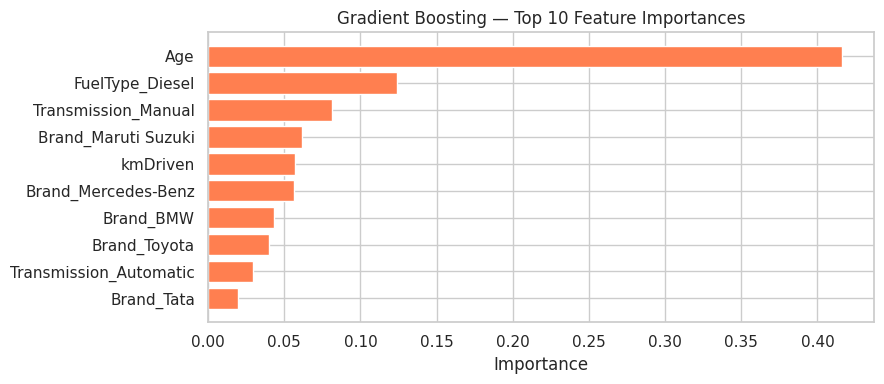

In [136]:
gb = GradientBoostingRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=5, random_state=42)
gb.fit(X_train, y_train)
print('Gradient Boosting trained (300 estimators, lr=0.05, depth=5).')

# Feature importance
fi_gb = pd.DataFrame({'Feature': X_train.columns, 'Importance': gb.feature_importances_})
fi_gb = fi_gb.sort_values('Importance', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(fi_gb['Feature'][::-1], fi_gb['Importance'][::-1], color='coral')
ax.set_title('Gradient Boosting — Top 10 Feature Importances', fontsize=12)
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()


### 4.5 K-Nearest Neighbors Regressor
Predicts target values by averaging the outputs of the 7 nearest data points.

In [137]:
knn = KNeighborsRegressor(n_neighbors=7)
knn.fit(X_train, y_train)
print('KNN trained (k=7).')


KNN trained (k=7).


<a id='5'></a>
## 5. Validation & Comparison

All trained models are assessed on the validation set for performance comparison.
Metrics are calculated in log-space due to the log transformation of the target variable.

The actual error in rupees is obtained by reversing the transformation using np.expm1.

In [138]:
def evaluate(name, model, X, y):
    pred = model.predict(X)
    return {
        'Model': name,
        'MAE':  mean_absolute_error(y, pred),
        'MSE':  mean_squared_error(y, pred),
        'R²':   r2_score(y, pred)
    }

models_dict = {
    'Linear Regression':   lr,
    'Decision Tree':       dt,
    'Random Forest':       rf,
    'Gradient Boosting':   gb,
    'KNN':                 knn,
}

val_results = pd.DataFrame([
    evaluate(name, m, X_val, y_val)
    for name, m in models_dict.items()
]).set_index('Model')

print('=== Validation Set Metrics ===')
print(val_results.sort_values('R²', ascending=False).to_string())


=== Validation Set Metrics ===
                     MAE    MSE     R²
Model                                 
Gradient Boosting 0.2956 0.1676 0.8077
KNN               0.3096 0.1788 0.7948
Random Forest     0.3126 0.1823 0.7908
Linear Regression 0.3073 0.1830 0.7900
Decision Tree     0.3834 0.3127 0.6412


The validation results are summarized in a table showing MAE, MSE, and R² scores for each model.
A bar chart is generated to visually compare model performance across different evaluation metrics.

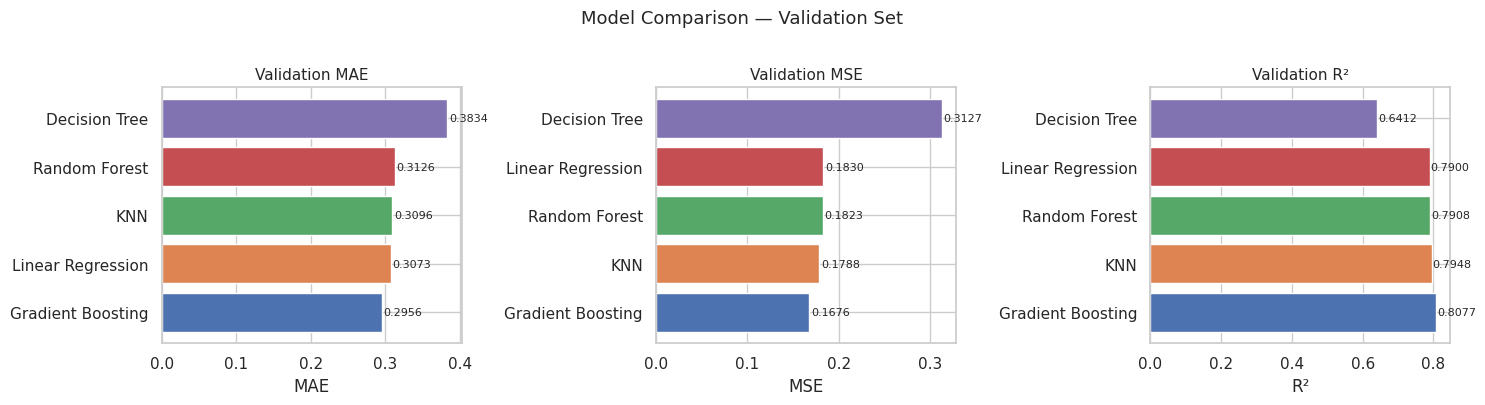

In [139]:
# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2']
metrics = ['MAE', 'MSE', 'R²']

for ax, metric in zip(axes, metrics):
    vals = val_results[metric].sort_values(ascending=(metric != 'R²'))
    bars = ax.barh(vals.index, vals.values, color=colors)
    ax.set_title(f'Validation {metric}', fontsize=11)
    ax.set_xlabel(metric)
    for bar, v in zip(bars, vals.values):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                f'{v:.4f}', va='center', fontsize=8)

plt.suptitle('Model Comparison — Validation Set', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


<a id='6'></a>
## 6. Ensemble Models

Based on the validation R² scores, the top three models selected are:

Gradient Boosting
KNN
Random Forest

These models are used to build ensemble techniques to improve overall prediction performance.


### 6a. Voting Regressor (Top 3 Models)
This method combines the predictions of the three best-performing models by averaging them equally to generate the final prediction.

In [140]:
voting = VotingRegressor(estimators=[
    ('gb',  gb),
    ('knn', knn),
    ('rf',  rf),
])
voting.fit(X_train, y_train)
print('Voting Regressor trained.')

val_v  = evaluate('Voting Ensemble', voting, X_val,  y_val)
print('\nVoting — Validation:')
for k, v in val_v.items():
    if k != 'Model': print(f'  {k}: {v:.4f}')


Voting Regressor trained.

Voting — Validation:
  MAE: 0.2924
  MSE: 0.1615
  R²: 0.8147


6b. Bayesian Stacking Ensemble (Bayesian Ridge Meta-Model)

A stacking method where predictions from the top models are used as input features to train a Bayesian Ridge meta-model.
The meta-model learns optimal weights for each base model and improves overall performance.

The meta-model is trained on validation predictions and evaluated on the test set to ensure proper generalization.

In [141]:
# Stack val predictions as meta-features
val_meta  = np.column_stack([gb.predict(X_val),  knn.predict(X_val),  rf.predict(X_val)])
test_meta = np.column_stack([gb.predict(X_test), knn.predict(X_test), rf.predict(X_test)])

# Train BayesianRidge meta-learner on validation predictions
br = BayesianRidge()
br.fit(val_meta, y_val)

print('Bayesian Ensemble trained.')
print(f'  Learned weights (coef_): GB={br.coef_[0]:.4f}, KNN={br.coef_[1]:.4f}, RF={br.coef_[2]:.4f}')

val_br = evaluate('Bayesian Ensemble', br,
                  val_meta,  y_val)
print('\nBayesian Ensemble — Validation:')
for k, v in val_br.items():
    if k != 'Model': print(f'  {k}: {v:.4f}')


Bayesian Ensemble trained.
  Learned weights (coef_): GB=0.5432, KNN=0.3734, RF=0.1265

Bayesian Ensemble — Validation:
  MAE: 0.2913
  MSE: 0.1582
  R²: 0.8184


The Bayesian Ridge meta-model is trained using validation predictions from the top models. The ensemble performance is then evaluated and compared using MAE, MSE, and R² metrics.

⚠️ The test data is not used during training to avoid data leakage.

=== Ensemble Comparison — Validation Set ===
                     MAE    MSE     R²
Model                                 
Voting Ensemble   0.2924 0.1615 0.8147
Bayesian Ensemble 0.2913 0.1582 0.8184


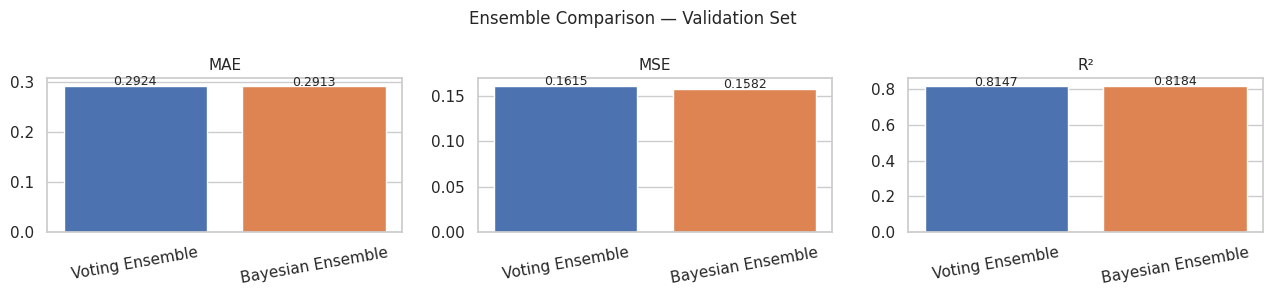

In [142]:
# Side-by-side ensemble comparison on validation set
ens_df = pd.DataFrame([val_v, val_br]).set_index('Model')
print('=== Ensemble Comparison — Validation Set ===')
print(ens_df.to_string())

fig, axes = plt.subplots(1, 3, figsize=(13, 3))
for ax, metric in zip(axes, ['MAE','MSE','R²']):
    ax.bar(ens_df.index, ens_df[metric], color=['#4C72B0','#DD8452'])
    ax.set_title(f'{metric}', fontsize=11)
    ax.tick_params(axis='x', rotation=10)
    for i, v in enumerate(ens_df[metric]):
        ax.text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=9)
plt.suptitle('Ensemble Comparison — Validation Set', fontsize=12)
plt.tight_layout()
plt.show()


<a id='7'></a>
## 7. Final Evaluation on Test Set

The test set has been **untouched until now**. We evaluate all 7 models once.


In [143]:
all_test_results = []
for name, m in models_dict.items():
    all_test_results.append(evaluate(name, m, X_test, y_test))

all_test_results.append(evaluate('Voting Ensemble',   voting, X_test,     y_test))
all_test_results.append(evaluate('Bayesian Ensemble', br,     test_meta,  y_test))

test_df = pd.DataFrame(all_test_results).set_index('Model')
print('=== Final Test Set Metrics ===')
print(test_df.sort_values('R²', ascending=False).to_string())


=== Final Test Set Metrics ===
                     MAE    MSE     R²
Model                                 
Bayesian Ensemble 0.2812 0.1594 0.7894
Voting Ensemble   0.2830 0.1601 0.7885
Gradient Boosting 0.2842 0.1656 0.7813
Random Forest     0.2992 0.1786 0.7641
KNN               0.3050 0.1804 0.7617
Linear Regression 0.3077 0.1853 0.7553
Decision Tree     0.3707 0.2863 0.6218


⚠️ The test set is used only once for final evaluation to ensure unbiased results.

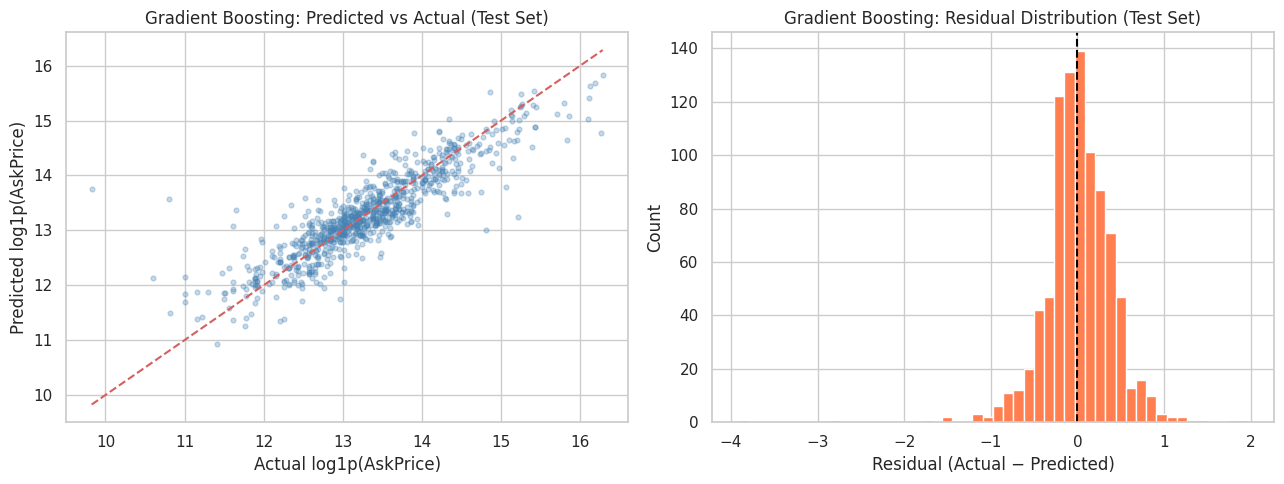

In [144]:
# Scatter: Predicted vs Actual (Gradient Boosting on test)
gb_pred_test = gb.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, gb_pred_test, alpha=0.3, s=12, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', linewidth=1.5)
axes[0].set_xlabel('Actual log1p(AskPrice)')
axes[0].set_ylabel('Predicted log1p(AskPrice)')
axes[0].set_title('Gradient Boosting: Predicted vs Actual (Test Set)')

residuals = y_test - gb_pred_test
axes[1].hist(residuals, bins=50, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_xlabel('Residual (Actual − Predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title('Gradient Boosting: Residual Distribution (Test Set)')

plt.tight_layout()
plt.show()


<a id='8'></a>
## 8. Results Summary Table

In [145]:
# Combined val + test summary
combined = []
all_models_eval = list(models_dict.keys()) + ['Voting Ensemble', 'Bayesian Ensemble']

for name in all_models_eval:
    if name in models_dict:
        m = models_dict[name]
        vp = m.predict(X_val);  tp = m.predict(X_test)
    elif name == 'Voting Ensemble':
        vp = voting.predict(X_val); tp = voting.predict(X_test)
    else:
        vp = br.predict(val_meta);  tp = br.predict(test_meta)

    combined.append({
        'Model':    name,
        'Val MAE':  mean_absolute_error(y_val,  vp),
        'Val MSE':  mean_squared_error(y_val,   vp),
        'Val R²':   r2_score(y_val,  vp),
        'Test MAE': mean_absolute_error(y_test, tp),
        'Test MSE': mean_squared_error(y_test,  tp),
        'Test R²':  r2_score(y_test, tp),
    })

summary_df = pd.DataFrame(combined).set_index('Model')
print('=== FULL RESULTS SUMMARY ===')
print(summary_df.to_string())


=== FULL RESULTS SUMMARY ===
                   Val MAE  Val MSE  Val R²  Test MAE  Test MSE  Test R²
Model                                                                   
Linear Regression   0.3073   0.1830  0.7900    0.3077    0.1853   0.7553
Decision Tree       0.3834   0.3127  0.6412    0.3707    0.2863   0.6218
Random Forest       0.3126   0.1823  0.7908    0.2992    0.1786   0.7641
Gradient Boosting   0.2956   0.1676  0.8077    0.2842    0.1656   0.7813
KNN                 0.3096   0.1788  0.7948    0.3050    0.1804   0.7617
Voting Ensemble     0.2924   0.1615  0.8147    0.2830    0.1601   0.7885
Bayesian Ensemble   0.2913   0.1582  0.8184    0.2812    0.1594   0.7894


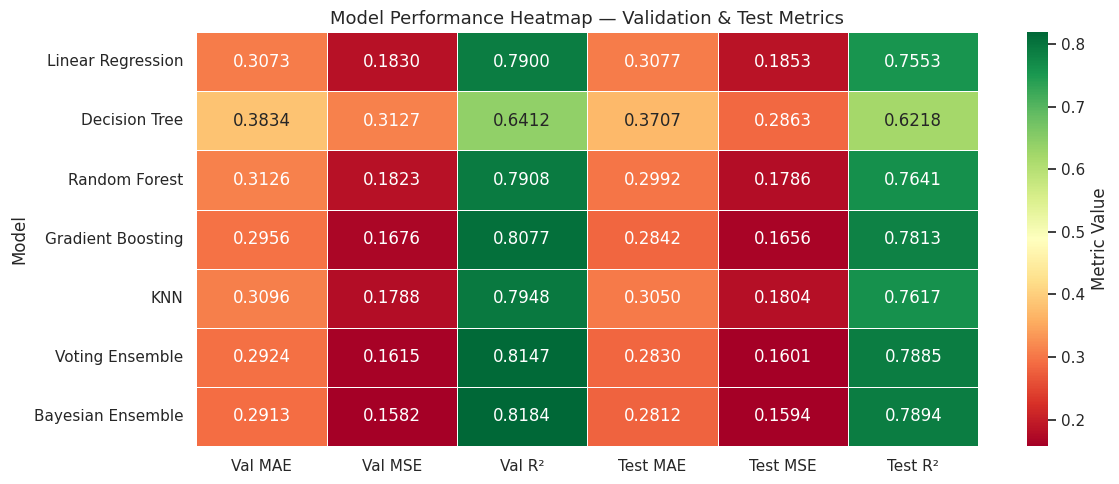

In [146]:
# Heatmap of all metrics
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(summary_df.astype(float), annot=True, fmt='.4f',
            cmap='RdYlGn', linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Metric Value'})
ax.set_title('Model Performance Heatmap — Validation & Test Metrics', fontsize=13)
plt.tight_layout()
plt.show()
